###Experiment 1: Gaussian Discriminant Classifier using Iris Dataset

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Select only Setosa (0) and Versicolor (1)
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

# Separate classes
X_setosa = X[y == 0]
X_versicolor = X[y == 1]

# Train-test split
X_train = np.vstack((X_setosa[:30], X_versicolor[:30]))
y_train = np.array([0]*30 + [1]*30)

X_test = np.vstack((X_setosa[30:], X_versicolor[30:]))
y_test = np.array([0]*20 + [1]*20)


(a) Estimate class-wise mean vectors and covariance matrices using Maximum Likeli-
hood Estimation.


In [29]:
def mle_mean_cov(X):
    mu = np.mean(X, axis=0)
    diff = X - mu
    cov = (diff.T @ diff) / X.shape[0]
    return mu, cov

# Class-wise estimates
mu_0, cov_0 = mle_mean_cov(X_setosa[:30])
mu_1, cov_1 = mle_mean_cov(X_versicolor[:30])

print("Mean Setosa:\n", mu_0)
print("Covariance Setosa:\n", cov_0)
print("\nMean Versicolor:\n", mu_1)
print("Covariance Versicolor:\n", cov_1)


Mean Setosa:
 [5.02666667 3.45       1.47333333 0.24666667]
Covariance Setosa:
 [[0.13395556 0.09766667 0.01737778 0.01542222]
 [0.09766667 0.1185     0.00166667 0.01866667]
 [0.01737778 0.00166667 0.03328889 0.00557778]
 [0.01542222 0.01866667 0.00557778 0.00982222]]

Mean Versicolor:
 [6.07       2.79       4.33333333 1.35333333]
Covariance Versicolor:
 [[0.2881     0.0987     0.18666667 0.05526667]
 [0.0987     0.10423333 0.08233333 0.04286667]
 [0.18666667 0.08233333 0.20422222 0.07055556]
 [0.05526667 0.04286667 0.07055556 0.04315556]]


(b) Implement the Gaussian discriminant function in the log-domain.

In [30]:
def gaussian_discriminant(x, mu, cov, prior):
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    diff = x - mu
    term1 = -0.5 * diff.T @ inv_cov @ diff
    term2 = -0.5 * np.log(det_cov)
    term3 = np.log(prior)
    return term1 + term2 + term3


(c) Classify all test samples

In [31]:
prior = 0.5
y_pred = []

for x in X_test:
    g0 = gaussian_discriminant(x, mu_0, cov_0, prior)
    g1 = gaussian_discriminant(x, mu_1, cov_1, prior)
    y_pred.append(0 if g0 > g1 else 1)

y_pred = np.array(y_pred)


(d) Classification accuracy

In [32]:
accuracy = np.mean(y_pred == y_test) * 100
print(f"Classification Accuracy: {accuracy:.2f}%")


Classification Accuracy: 100.00%


(e) Decision boundary (first two features only)

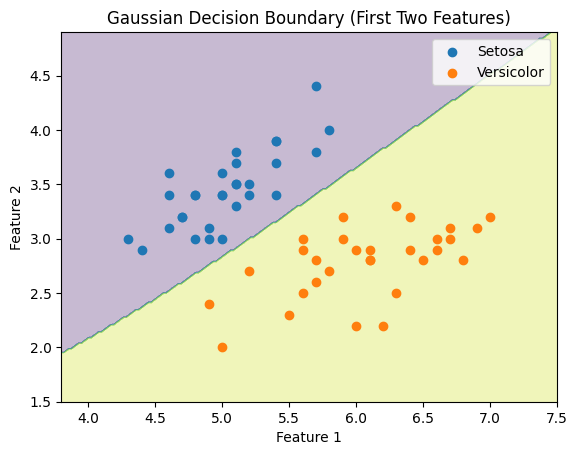

In [33]:
# Use first two features
X2_train = X_train[:, :2]

# Recompute MLE using only first two features
mu0_2, cov0_2 = mle_mean_cov(X2_train[:30])
mu1_2, cov1_2 = mle_mean_cov(X2_train[30:])

# Meshgrid
x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = np.zeros(xx.shape)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point = np.array([xx[i, j], yy[i, j]])
        g0 = gaussian_discriminant(point, mu0_2, cov0_2, prior)
        g1 = gaussian_discriminant(point, mu1_2, cov1_2, prior)
        Z[i, j] = 0 if g0 > g1 else 1

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2_train[:30, 0], X2_train[:30, 1], label='Setosa')
plt.scatter(X2_train[30:, 0], X2_train[30:, 1], label='Versicolor')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Gaussian Decision Boundary (First Two Features)')
plt.show()


###Experiment 2: Linear vs Quadratic Gaussian Classifiers on Iris

(a) Gaussian classifier with identical covariance matrices (LDA)

In [34]:
# Split training data by class
X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

# Means
mu0 = np.mean(X0, axis=0)
mu1 = np.mean(X1, axis=0)

# Pooled covariance
def pooled_covariance(X0, X1, mu0, mu1):
    N0, N1 = X0.shape[0], X1.shape[0]
    cov0 = (X0 - mu0).T @ (X0 - mu0)
    cov1 = (X1 - mu1).T @ (X1 - mu1)
    return (cov0 + cov1) / (N0 + N1)

cov_shared = pooled_covariance(X0, X1, mu0, mu1)


prior = 0.5
inv_cov = np.linalg.inv(cov_shared)
det_cov = np.linalg.det(cov_shared)

y_pred_lda = []

for x in X_test:
    g0 = -0.5*(x-mu0).T @ inv_cov @ (x-mu0) - 0.5*np.log(det_cov) + np.log(prior)
    g1 = -0.5*(x-mu1).T @ inv_cov @ (x-mu1) - 0.5*np.log(det_cov) + np.log(prior)
    y_pred_lda.append(0 if g0 > g1 else 1)

y_pred_lda = np.array(y_pred_lda)


(b) Implement a Gaussian classifier assuming class-specific covariance matrices.

In [35]:
# Class-specific covariances (MLE)
def mle_cov(X, mu):
    diff = X - mu
    return (diff.T @ diff) / X.shape[0]

cov0 = mle_cov(X0, mu0)
cov1 = mle_cov(X1, mu1)

y_pred_qda = []

for x in X_test:
    g0 = -0.5*(x-mu0).T @ np.linalg.inv(cov0) @ (x-mu0) \
         - 0.5*np.log(np.linalg.det(cov0)) + np.log(prior)

    g1 = -0.5*(x-mu1).T @ np.linalg.inv(cov1) @ (x-mu1) \
         - 0.5*np.log(np.linalg.det(cov1)) + np.log(prior)

    y_pred_qda.append(0 if g0 > g1 else 1)

y_pred_qda = np.array(y_pred_qda)


(c) Classification accuracy for both cases

In [36]:
acc_lda = np.mean(y_pred_lda == y_test) * 100
acc_qda = np.mean(y_pred_qda == y_test) * 100

print(f"LDA Accuracy (shared covariance): {acc_lda:.2f}%")
print(f"QDA Accuracy (class-specific covariance): {acc_qda:.2f}%")


LDA Accuracy (shared covariance): 100.00%
QDA Accuracy (class-specific covariance): 100.00%


(d) Numerical difference in accuracy

In [37]:
accuracy_diff = abs(acc_qda - acc_lda)
print(f"Difference in accuracy: {accuracy_diff:.2f}%")


Difference in accuracy: 0.00%


###Experiment 3: Bayesian Decision Theory for Discrete Features

In [38]:
import numpy as np
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train = X[:300]
y_train = y[:300]

X_test = X[300:]
y_test = y[300:]

# Compute feature-wise means from training data
mu = np.mean(X_train, axis=0)

# Binarize
X_train_bin = (X_train > mu).astype(int)
X_test_bin = (X_test > mu).astype(int)


(a) Estimate class-conditional probabilities

In [39]:
# Separate classes
X0 = X_train_bin[y_train == 0]
X1 = X_train_bin[y_train == 1]

# Class priors
P_w0 = X0.shape[0] / X_train_bin.shape[0]
P_w1 = X1.shape[0] / X_train_bin.shape[0]

# Conditional probabilities P(x_j = 1 | w_i)
P_x1_w0 = np.mean(X0, axis=0)
P_x1_w1 = np.mean(X1, axis=0)


(b) Compute posterior probabilities

In [40]:
def log_likelihood(x, P_x1):
    return np.sum(x * np.log(P_x1 + 1e-9) +
                  (1 - x) * np.log(1 - P_x1 + 1e-9))


(c) Bayes risk minimization

In [41]:
Lambda = np.array([[0, 1],
                   [2, 0]])


y_pred = []

for x in X_test_bin:
    # Log-posteriors
    log_p0 = log_likelihood(x, P_x1_w0) + np.log(P_w0)
    log_p1 = log_likelihood(x, P_x1_w1) + np.log(P_w1)

    # Convert to probabilities
    max_log = max(log_p0, log_p1)
    p0 = np.exp(log_p0 - max_log)
    p1 = np.exp(log_p1 - max_log)
    norm = p0 + p1
    p0 /= norm
    p1 /= norm

    posteriors = np.array([p0, p1])

    # Compute risks
    risk_0 = Lambda[0] @ posteriors
    risk_1 = Lambda[1] @ posteriors

    # Decision
    y_pred.append(0 if risk_0 < risk_1 else 1)

y_pred = np.array(y_pred)


(d) Confusion matrix & accuracy

In [42]:
# Confusion matrix
conf_matrix = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test, y_pred):
    conf_matrix[true, pred] += 1

accuracy = np.mean(y_pred == y_test) * 100

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nClassification Accuracy: {accuracy:.2f}%")


Confusion Matrix:
[[ 65   1]
 [ 15 188]]

Classification Accuracy: 94.05%


###Experiment 4: Bias in MLE Covariance Estimation (Iris Dataset)

Define covariance estimators

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Use only Setosa (class 0)
X_setosa = X[y == 0]


def cov_mle(X):
    mu = np.mean(X, axis=0)
    diff = X - mu
    return (diff.T @ diff) / X.shape[0]

def cov_bessel(X):
    mu = np.mean(X, axis=0)
    diff = X - mu
    return (diff.T @ diff) / (X.shape[0] - 1)




Compute covariance traces for different sample sizes

In [44]:
sample_sizes = [5, 10, 20, 30]

trace_mle = []
trace_bessel = []

for n in sample_sizes:
    X_n = X_setosa[:n]
    cov_m = cov_mle(X_n)
    cov_b = cov_bessel(X_n)

    trace_mle.append(np.trace(cov_m))
    trace_bessel.append(np.trace(cov_b))

for i, n in enumerate(sample_sizes):
    print(f"n = {n}:  Trace MLE = {trace_mle[i]:.4f},  Trace Bessel = {trace_bessel[i]:.4f}")



n = 5:  Trace MLE = 0.0920,  Trace Bessel = 0.1150
n = 10:  Trace MLE = 0.1774,  Trace Bessel = 0.1971
n = 20:  Trace MLE = 0.3594,  Trace Bessel = 0.3783
n = 30:  Trace MLE = 0.2956,  Trace Bessel = 0.3058


Plot trace vs sample size

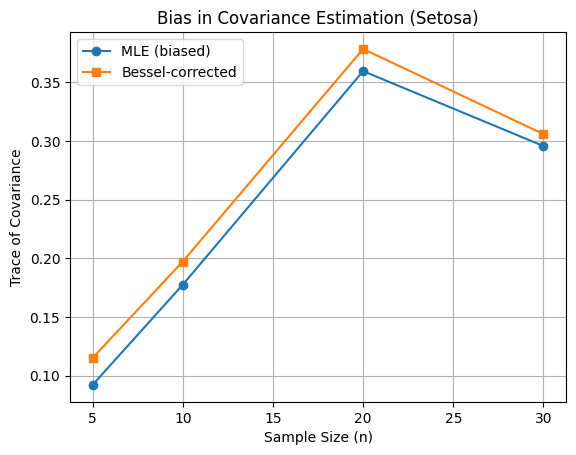

In [45]:
plt.plot(sample_sizes, trace_mle, marker='o', label='MLE (biased)')
plt.plot(sample_sizes, trace_bessel, marker='s', label='Bessel-corrected')
plt.xlabel('Sample Size (n)')
plt.ylabel('Trace of Covariance')
plt.title('Bias in Covariance Estimation (Setosa)')
plt.legend()
plt.grid(True)
plt.show()


###Experiment 5: MAP Estimation of Gaussian Mean (Iris Dataset)

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(42)

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Use only Versicolor
X_ver = X[y == 1]

# Global mean
mu0 = np.mean(X, axis=0)

# Known covariance
mu_ver_full = np.mean(X_ver, axis=0)
diff = X_ver - mu_ver_full
Sigma = (diff.T @ diff) / X_ver.shape[0]

Sigma_inv = np.linalg.inv(Sigma)

# Prior covariance and inverse
Sigma_prior = 0.25 * np.eye(X.shape[1])
Sigma_prior_inv = np.linalg.inv(Sigma_prior)


(a) Mean estimation using MLE

In [47]:
def mle_mean(X):
    return np.mean(X, axis=0)


(b) Mean estimation using MAP

In [48]:
def map_mean(X, mu0, Sigma_inv, Sigma_prior_inv):
    n = X.shape[0]
    x_bar = np.mean(X, axis=0)

    A = n * Sigma_inv + Sigma_prior_inv
    b = n * Sigma_inv @ x_bar + Sigma_prior_inv @ mu0

    return np.linalg.inv(A) @ b


(c) Mean Squared Error (MSE)

In [49]:
def mse(mu_hat, mu_true):
    return np.mean((mu_hat - mu_true)**2)

sample_sizes = [5, 10, 20, 40]

mse_mle = []
mse_map = []

for n in sample_sizes:
    X_n = X_ver[:n]

    mu_mle = mle_mean(X_n)
    mu_map = map_mean(X_n, mu0, Sigma_inv, Sigma_prior_inv)

    mse_mle.append(mse(mu_mle, mu_ver_full))
    mse_map.append(mse(mu_map, mu_ver_full))


(d) Plot MSE vs sample size

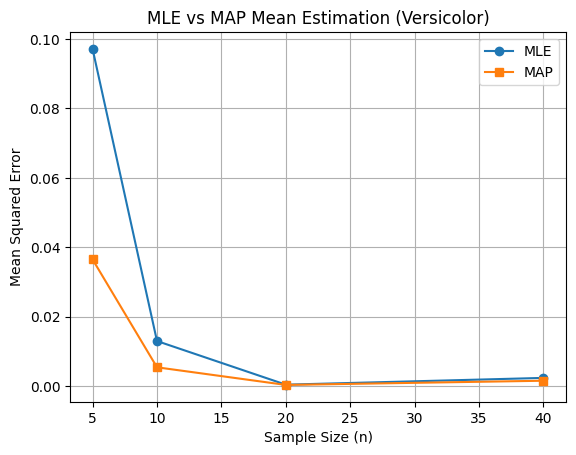

In [50]:
plt.plot(sample_sizes, mse_mle, marker='o', label='MLE')
plt.plot(sample_sizes, mse_map, marker='s', label='MAP')
plt.xlabel('Sample Size (n)')
plt.ylabel('Mean Squared Error')
plt.title('MLE vs MAP Mean Estimation (Versicolor)')
plt.legend()
plt.grid(True)
plt.show()
